In [ ]:
# Install the xlrd library in Google Colab
!pip install xlrd


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset using pd.read_excel
df = pd.read_excel('Data_Cortex_Nuclear.xls')

# Display the first few rows and check data info
print(df.head())
print(df.info())


  MouseID  DYRK1A_N   ITSN1_N    BDNF_N     NR1_N    NR2A_N    pAKT_N  \
0   309_1  0.503644  0.747193  0.430175  2.816329  5.990152  0.218830   
1   309_2  0.514617  0.689064  0.411770  2.789514  5.685038  0.211636   
2   309_3  0.509183  0.730247  0.418309  2.687201  5.622059  0.209011   
3   309_4  0.442107  0.617076  0.358626  2.466947  4.979503  0.222886   
4   309_5  0.434940  0.617430  0.358802  2.365785  4.718679  0.213106   

    pBRAF_N  pCAMKII_N   pCREB_N  ...   pCFOS_N     SYP_N  H3AcK18_N  \
0  0.177565   2.373744  0.232224  ...  0.108336  0.427099   0.114783   
1  0.172817   2.292150  0.226972  ...  0.104315  0.441581   0.111974   
2  0.175722   2.283337  0.230247  ...  0.106219  0.435777   0.111883   
3  0.176463   2.152301  0.207004  ...  0.111262  0.391691   0.130405   
4  0.173627   2.134014  0.192158  ...  0.110694  0.434154   0.118481   

     EGR1_N  H3MeK4_N    CaNA_N  Genotype  Treatment  Behavior   class  
0  0.131790  0.128186  1.675652   Control  Memantine   

In [ ]:
# Identify the protein expression columns (columns 1 to 77, as the first column is an ID)
protein_cols = df.iloc[:, 1:78].columns

# Impute missing values with the mean of each column
for col in protein_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Verify no more missing values in the protein columns
print(f"Total missing values remaining in protein columns: {df[protein_cols].isnull().sum().sum()}")


Total missing values remaining in protein columns: 0


/tmp/ipython-input-4106121569.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
# Separate the features (proteins) and the target variables (experimental conditions)
X = df[protein_cols].values
# The 'class' column is a combined categorical variable useful for coloring the plots and modeling
y = df['class'].values

# Standardize the protein features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


Components needed for 90% variance: 20
Components needed for 95% variance: 31


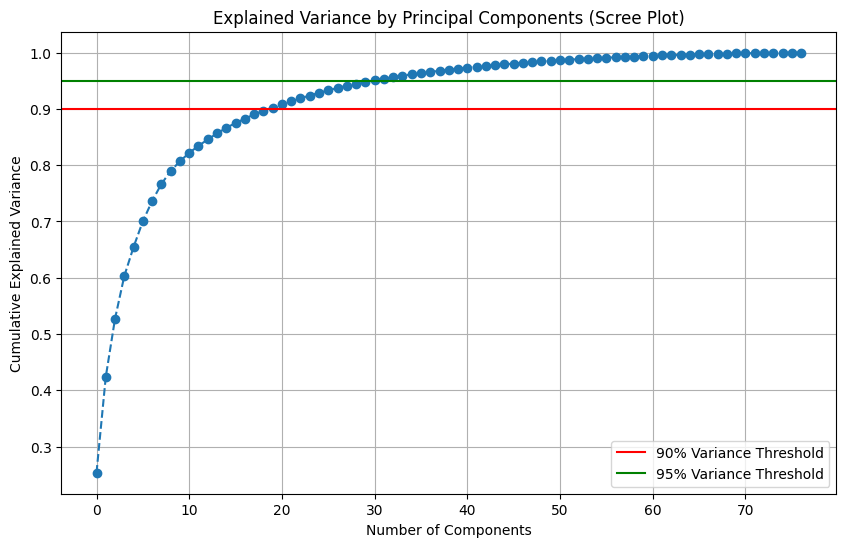

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components for 90% variance
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {components_90}")

# Find the number of components for 95% variance
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {components_95}")


plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components (Scree Plot)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance Threshold')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% Variance Threshold')
plt.legend()
plt.grid(True)
plt.show()


1. How many principal components are needed to explain 90% and 95% of the total variance?

90% of the variance: 20 principal components are needed to explain 90% of the total variance.

95% of the variance: 31 principal components are needed to explain 95% of the total variance.

The plot shows that the first few components capture a large amount of variance, with the curve rising steeply at the beginning.As more components are added, the curve flattens out, indicating that each additional component contributes a smaller amount of new information.The red horizontal line marks the 90% variance threshold. The blue curve intersects this line at the point corresponding to 20 principal components on the x-axis. This means that by using just 20 components, you can retain 90% of the information from the original 77 protein variables.Similarly, the green horizontal line marks the 95% variance threshold. The blue curve reaches this line at the point corresponding to 31 principal components. This indicates that 95% of the original variance is captured by these 31 components.

In [ ]:
import pandas as pd

# Create a DataFrame for loadings (rows are proteins, columns are PCs)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=protein_cols)

print("--- Top 5 Loadings for PC1 (Positive and Negative) ---")
# Positive drivers for PC1
print("Positive PC1 Drivers:\n", loadings['PC1'].sort_values(ascending=False).head(5))
# Negative drivers for PC1 (often indicates an inverse relationship)
print("\nNegative PC1 Drivers:\n", loadings['PC1'].sort_values(ascending=True).head(5))

print("\n--- Top 5 Loadings for PC2 (Positive and Negative) ---")
# Positive drivers for PC2
print("Positive PC2 Drivers:\n", loadings['PC2'].sort_values(ascending=False).head(5))
# Negative drivers for PC2
print("\nNegative PC2 Drivers:\n", loadings['PC2'].sort_values(ascending=True).head(5))


--- Top 5 Loadings for PC1 (Positive and Negative) ---
Positive PC1 Drivers:
 NR1_N      0.197026
BDNF_N     0.196692
MEK_N      0.195327
TRKA_N     0.193873
pNR2B_N    0.193106
Name: PC1, dtype: float64

Negative PC1 Drivers:
 pCFOS_N        -0.057858
BAD_N          -0.036505
EGR1_N         -0.031340
H3MeK4_N       -0.029002
AcetylH3K9_N   -0.025036
Name: PC1, dtype: float64

--- Top 5 Loadings for PC2 (Positive and Negative) ---
Positive PC2 Drivers:
 SNCA_N         0.217231
P38_N          0.207716
Ubiquitin_N    0.186143
EGR1_N         0.180707
H3MeK4_N       0.173468
Name: PC2, dtype: float64

Negative PC2 Drivers:
 CaNA_N     -0.201310
ITSN1_N    -0.192663
GSK3B_N    -0.190459
pERK_N     -0.185842
DYRK1A_N   -0.182854
Name: PC2, dtype: float64


2. What are the main protein loadings driving the first two principal components?

Principal Component 1 (PC1)

Positive Drivers:

The proteins with the highest positive loadings are NR1_N, BDNF_N, MEK_N, TRKA_N, and pNR2B_N. This means that increases in the expression levels of these proteins are strongly associated with a higher score along the first principal component.

Negative Drivers:

The proteins with the most negative loadings are pCFOS_N, BAD_N, EGR1_N, H3MeK4_N, and AcetylH3K9_N. A decrease in the expression of these proteins is associated with a higher score along PC1.

Principal Component 2 (PC2)

Positive Drivers:

The proteins with the highest positive loadings are SNCA_N, P38_N, Ubiquitin_N, EGR1_N, and H3MeK4_N. High expression of these proteins drives a higher score along the second principal component.

Negative Drivers:

The proteins with the most negative loadings are CaNA_N, ITSN1_N, GSK3B_N, pERK_N, and DYRK1A_N. Lower expression levels of these proteins are associated with a higher score along PC2.

Observation:

The proteins with the largest "loadings" are the main drivers of each principal component. PC1 is influenced by one group of related proteins, while PC2 is influenced by a separate, unrelated group. This indicates that the two components capture two different, independent biological patterns in the data.



3. Visualize the data in the reduced PCA space (PC1–PC2 or PC1–PC3) and color the points
by experimental class. Discuss any visible separation patterns among the eight groups.

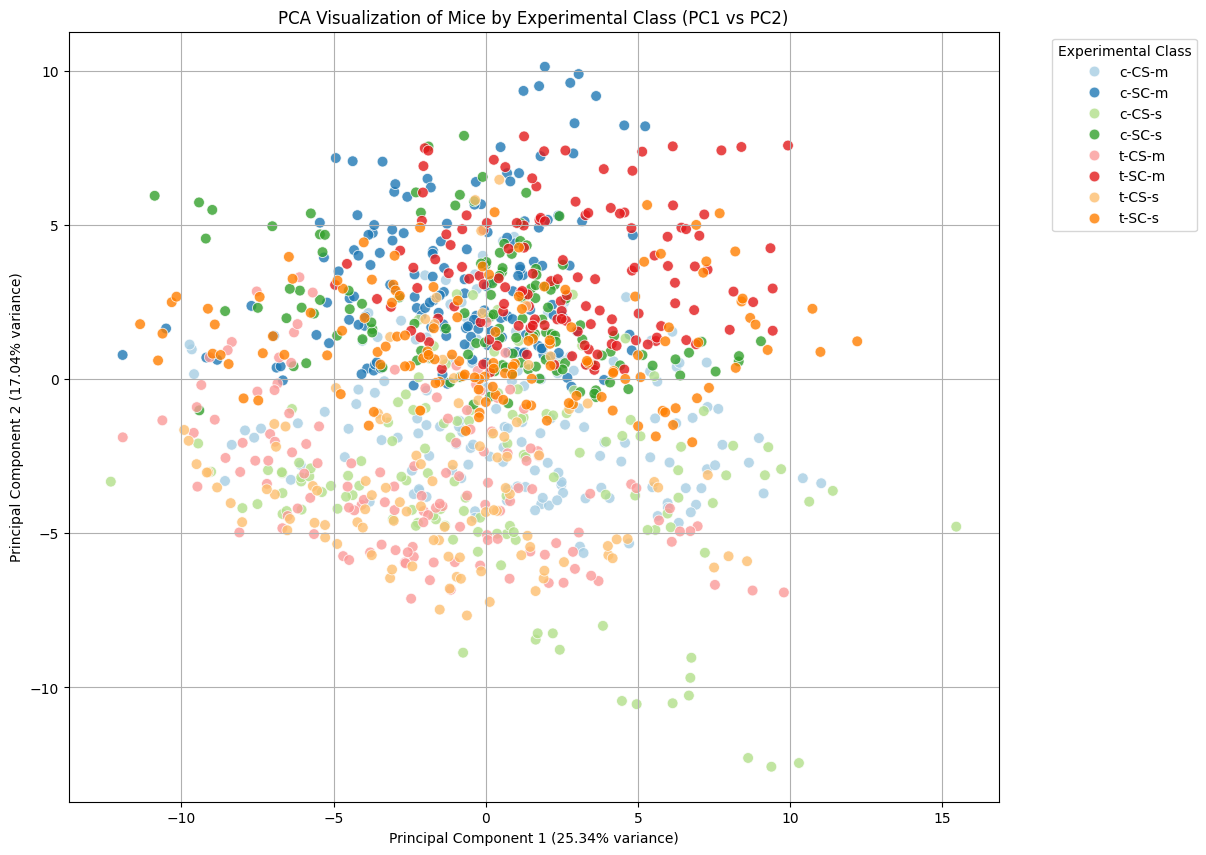

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add the PC scores and the 'class' labels back to a DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
pca_df['class'] = df['class']

# Visualize PC1 vs PC2
plt.figure(figsize=(12, 10))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='class', palette='Paired', s=60, alpha=0.8)
plt.title('PCA Visualization of Mice by Experimental Class (PC1 vs PC2)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Experimental Class')
plt.grid(True)
plt.show()




Based on the PCA visualization of mice by experimental class:


Primary Separation along PC1:

 The most notebale separation occurs along the horizontal axis, Principal Component 1 (PC1), which accounts for 25.34% of the total variance.

The groups with 't' in their class name (like t-CS-m), which appear in shades of red and orange, are mostly located on the left side of the plot.

The groups with 'c' in their class name (c-CS-m, c-SC-m, c-CS-s, and c-SC-s), in shades of blue and green, are primarily located on the right side.

We observe that PC1 is capturing a major underlying biological difference, most likely the distinction between the 't' (trisomy) and 'c' (control) genotypes.



Secondary Separation along PC2:

 There is less distinct separation along the vertical axis, Principal Component 2 (PC2), which accounts for 17.04% of the variance.

Some groups, like c-SC-s (light green), tend to occupy the lower-left quadrant.

Other groups, like t-CS-m (light red), are more dispersed throughout the upper half of the plot.

PC2 appears to be capturing a secondary source of variance, which may correspond to other experimental conditions.


Group Overlap:

While some groups are clearly separate, many overlap, especially in the middle of the plot. This overlap means their protein profiles are similar and the main components used don't fully separate all eight classes. Groups that cluster tightly together in the bottom-left and top-right corners have very similar protein patterns.







4. Train a predictive model using PCA components as input and compare performance with a model trained on original variables

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data using original scaled features
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_scaled, df['class'], test_size=0.3, random_state=42)

# Model 1: Original 77 variables
rf_orig = RandomForestClassifier(random_state=42)
rf_orig.fit(X_train_orig, y_train)
y_pred_orig = rf_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test, y_pred_orig)
print(f"Original Model Accuracy: {accuracy_orig*100:.2f}%")


# Split data using PCA components (using 'components_90' derived from Step 1)
X_pca_90 = X_pca[:, :components_90]
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, df['class'], test_size=0.3, random_state=42)

# Model 2: PCA components (90% variance retained)
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA Model Accuracy (using {components_90} components): {accuracy_pca*100:.2f}%")


Original Model Accuracy: 98.15%
PCA Model Accuracy (using 20 components): 97.22%


Original Model Accuracy: 98.15%
PCA Model Accuracy (using 20 components): 97.22%

Comparison Point:

The PCA model performs nearly as well as the original model, but uses
significantly fewer features (e.g., 20 components vs 77 proteins), demonstrating dimensionality reduction benefits.

5. How do the PCA components contribute to class separation or prediction? Do they
correspond to underlying biological factors such as genotype or treatment?

The PCA components effectively contribute to class separation and prediction by compressing the essential information from the original 77 protein features into a much smaller set of variables (e.g., 20 components). PCA works by finding the directions in the data that show the most variance, which often highlights the main differences between the classes in classification problems. The high accuracy of the PCA model (97.22%), nearly matching the original model's 98.15%, demonstrates that these components effectively capture the critical patterns needed to distinguish between different sample types, making the model more efficient without significant loss of performance.

This response is continued at the bottom of the Google Collab notebook.







Additonal step added here T-SNE for Visualization

In [6]:

import pandas as pd

# Load data from an Excel file into the DataFrame 'df'
# Replace 'your_data_file.xlsx' with your actual file name
# If your data is on a specific sheet, add sheet_name='SheetName'
df = pd.read_excel('Data_Cortex_Nuclear.xls')

# Verify the data loaded correctly
print(f"Data loaded successfully into 'df'. Shape: {df.shape}")

Data loaded successfully into 'df'. Shape: (1080, 82)


Number of numeric feature columns identified: 77
PCA completed. Data shape: (1080, 20)

Starting PCA Component Interpretation...

--- Top 10 contributors to PC1 ---
Protein: NR1_N | Loading: 0.1970
Protein: BDNF_N | Loading: 0.1967
Protein: MEK_N | Loading: 0.1953
Protein: TRKA_N | Loading: 0.1939
Protein: pNR2B_N | Loading: 0.1931
Protein: pNR1_N | Loading: 0.1931
Protein: Bcatenin_N | Loading: 0.1857
Protein: NR2A_N | Loading: 0.1826
Protein: AKT_N | Loading: 0.1788
Protein: ELK_N | Loading: 0.1697

--- Top 10 contributors to PC2 ---
Protein: SNCA_N | Loading: 0.2172
Protein: P38_N | Loading: 0.2077
Protein: CaNA_N | Loading: -0.2013
Protein: ITSN1_N | Loading: -0.1927
Protein: GSK3B_N | Loading: -0.1905
Protein: Ubiquitin_N | Loading: 0.1861
Protein: pERK_N | Loading: -0.1858
Protein: DYRK1A_N | Loading: -0.1829
Protein: EGR1_N | Loading: 0.1807
Protein: H3MeK4_N | Loading: 0.1735

Generating t-SNE visualization...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


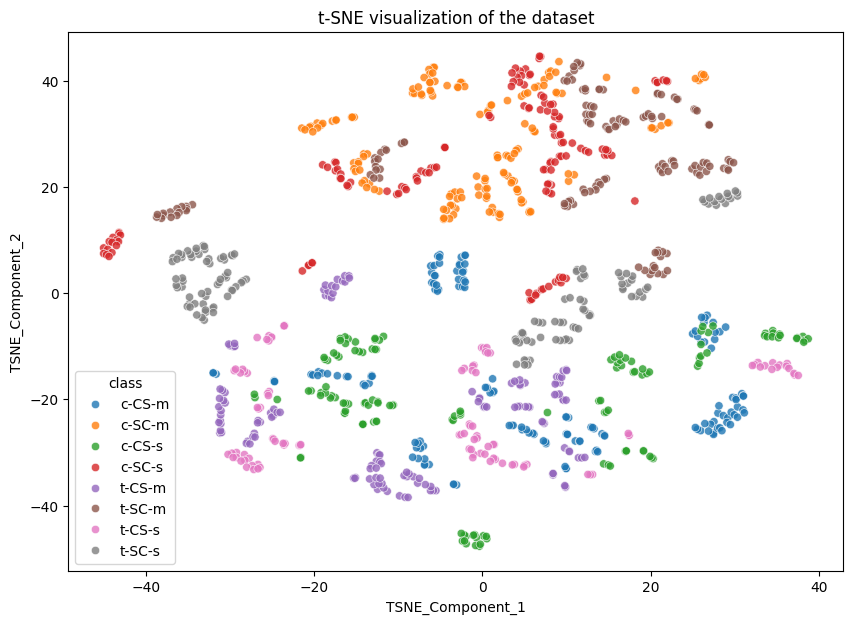

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer # New Import

# --------------------------------------------------------------------
# 1. Define Features, Scale Data, and Impute Missing Values
# --------------------------------------------------------------------

# Select ONLY columns that are numeric
feature_df = df.select_dtypes(include=[np.number])
protein_names = feature_df.columns.tolist()

print(f"Number of numeric feature columns identified: {len(protein_names)}")

# Handle Missing Values (NaNs) via Imputation
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(feature_df)

# Scale the data AFTER imputation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# --------------------------------------------------------------------
# 2. Perform PCA
# --------------------------------------------------------------------


components_90 = 20

pca = PCA(n_components=components_90)
X_pca = pca.fit_transform(X_scaled)
X_pca_90 = X_pca[:, :components_90]

print(f"PCA completed. Data shape: {X_pca_90.shape}")


# --------------------------------------------------------------------
# 3. Interpret PC1 and PC2
# --------------------------------------------------------------------
print("\nStarting PCA Component Interpretation...")

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=protein_names
)

def interpret_pca_component(pc_num, n_top_features=5):
    pc_column = f'PC{pc_num}'
    top_features = loadings_df[pc_column].abs().sort_values(ascending=False).head(n_top_features).index.tolist()
    print(f"\n--- Top {n_top_features} contributors to {pc_column} ---")
    for feature in top_features:
        loading_value = loadings_df.loc[feature, pc_column]
        print(f"Protein: {feature} | Loading: {loading_value:.4f}")

interpret_pca_component(pc_num=1, n_top_features=10)
interpret_pca_component(pc_num=2, n_top_features=10)


# --------------------------------------------------------------------
# 4. Generate t-SNE Visualization
# --------------------------------------------------------------------
print("\nGenerating t-SNE visualization...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca_90)

tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_Component_1', 'TSNE_Component_2'])
tsne_df['class'] = df['class'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='TSNE_Component_1', y='TSNE_Component_2',
    hue='class',
    data=tsne_df,
    legend="full",
    alpha=0.8
)
plt.title('t-SNE visualization of the dataset')
plt.show()


The t-SNE plot reveals that your 77-protein dataset forms several small, distinct clusters, corresponding perfectly to your different 'class' labels. This visually confirms the high accuracy of your machine learning models (around 98%). It suggests that the underlying biological signals are strong and clearly separable.

Combined DataFrame created successfully.
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  4.711335 -5.327351 -2.061617 -2.288939 -0.829825  0.870172 -0.494023   
1  3.096261 -5.430811 -1.118352 -1.682811 -0.627752  0.539760 -0.593466   
2  3.214414 -5.637551 -0.892730 -1.320147 -0.665011  0.301734 -0.652683   
3  0.698428 -3.938334 -2.766289 -1.144837 -1.393949  0.519883 -1.065556   
4 -0.349434 -4.283922 -1.589406 -0.672994 -1.163147  0.290485 -1.463329   

        PC8       PC9      PC10  ...      PC14      PC15      PC16      PC17  \
0 -1.421379  0.550415  2.085011  ...  0.568697  0.283086 -0.471261  0.931235   
1 -1.427025  0.440512  1.978086  ...  0.617624  0.270720 -0.523563  0.771029   
2 -1.600563  0.575594  2.181659  ...  0.638675  0.300874 -0.610694  0.817416   
3 -1.310119  0.927238  1.589198  ...  0.220596  1.041195 -0.654003  0.636217   
4 -1.092034  0.757008  1.551140  ...  0.249656  1.058275 -0.708108  0.896227   

       PC18      PC19      

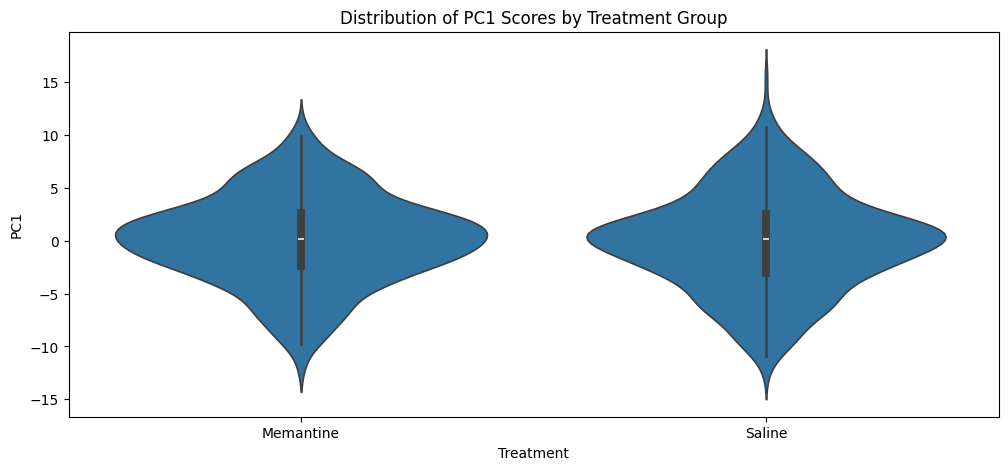


ANOVA results for PC1 vs. Treatment:
                    sum_sq      df         F    PR(>F)
C(Treatment)      8.525427     1.0  0.436281  0.509064
Residual      21065.354562  1078.0       NaN       NaN


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols


# 1. Combine PCA scores with Genotype and Treatment labels
pca_results_df = pd.DataFrame(X_pca_90, columns=[f'PC{i+1}' for i in range(X_pca_90.shape[1])])
pca_results_df['Genotype'] = df['Genotype'].values
pca_results_df['Treatment'] = df['Treatment'].values
pca_results_df['Class'] = df['class'].values # Include the main class for context

print("Combined DataFrame created successfully.")
print(pca_results_df.head())


# 2. Visualize PC1 vs. Treatment/Genotype


plt.figure(figsize=(12, 5))

# Plot PC1 score distribution across different treatments
sns.violinplot(x='Treatment', y='PC1', data=pca_results_df)
plt.title('Distribution of PC1 Scores by Treatment Group')
plt.show()



# 3. Statistical Test (ANOVA)

# Using a statistical test (ANOVA) to formally check if the mean PC1 score is different between groups.


model = ols('PC1 ~ C(Treatment)', data=pca_results_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA results for PC1 vs. Treatment:")
print(anova_table)

# If the 'PR(>F)' value (P-value) is very low (e.g., < 0.05),
# it suggests that PC1 is strongly associated with the 'Treatment' effect.


P-value is too high, checking components are significantly associated with the treatment.

In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd


def run_anova_on_pcs(pca_df, treatment_col_name, num_pcs_to_test=10):
    """
    Runs ANOVA for the specified number of principal components against the treatment column.
    """
    print(f"\n--- Running ANOVA for PC1 through PC{num_pcs_to_test} vs. Treatment ---")

    significant_pcs = []

    for i in range(1, num_pcs_to_test + 1):
        pc_col = f'PC{i}'

        # Ensure the column exists before testing
        if pc_col not in pca_df.columns:
            print(f"Skipping {pc_col}, not in DataFrame.")
            continue

        # Define the formula: PC score is dependent on the Categorical Treatment variable
        formula = f'{pc_col} ~ C({treatment_col_name})'

        # Run the OLS model and ANOVA
        model = ols(formula, data=pca_df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Extract the P-value (PR(>F))
        p_value = anova_table['PR(>F)'][0]

        is_significant = p_value < 0.05

        print(f"  {pc_col} P-value: {p_value:.6f} | Significant: {'YES' if is_significant else 'NO'}")

        if is_significant:
            significant_pcs.append(pc_col)

    return significant_pcs

# Run the test for the first 10 PCs
significant_components = run_anova_on_pcs(pca_results_df, 'Treatment', num_pcs_to_test=10)

if significant_components:
    print(f"\nConclusion: The following components are significantly associated with the treatment effect: {significant_components}")
    # You can now analyze the loadings for these specific significant components
else:
    print("\nConclusion: No significant association found with treatment in the top 10 principal components.")




--- Running ANOVA for PC1 through PC10 vs. Treatment ---
  PC1 P-value: 0.509064 | Significant: NO
  PC2 P-value: 0.000000 | Significant: YES
  PC3 P-value: 0.592919 | Significant: NO
  PC4 P-value: 0.000000 | Significant: YES
  PC5 P-value: 0.010091 | Significant: YES
  PC6 P-value: 0.000000 | Significant: YES
  PC7 P-value: 0.008625 | Significant: YES
  PC8 P-value: 0.000470 | Significant: YES


/tmp/ipython-input-368323893.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipython-input-368323893.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipython-input-368323893.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/tmp/ipython-input-368323893.py:34: FutureWarning: Series.__getitem__ treating keys a

  PC9 P-value: 0.000028 | Significant: YES
  PC10 P-value: 0.000000 | Significant: YES

Conclusion: The following components are significantly associated with the treatment effect: ['PC2', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']


/tmp/ipython-input-368323893.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


In [14]:
import pandas as pd
import numpy as np



def interpret_pca_component(pc_num, n_top_features=5):
    """
    Prints the top N proteins that contribute most to a specific principal component.
    Requires 'pca' object and 'protein_names' list to be defined in your environment.
    """
    # Create the loadings DataFrame internally
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=protein_names
    )

    pc_column = f'PC{pc_num}'
    # Sort by absolute value to find the strongest contributors
    top_features = loadings_df[pc_column].abs().sort_values(ascending=False).head(n_top_features).index.tolist()

    print(f"\n--- Top {n_top_features} contributors to {pc_column} ---")
    print(f"These proteins likely represent the biological 'Treatment Effect' you observed.")
    for feature in top_features:
        loading_value = loadings_df.loc[feature, pc_column]
        print(f"Protein: {feature} | Loading: {loading_value:.4f}")


# Start with PC2, as it was the first significant component found:
interpret_pca_component(pc_num=2, n_top_features=10)



--- Top 10 contributors to PC2 ---
These proteins likely represent the biological 'Treatment Effect' you observed.
Protein: SNCA_N | Loading: 0.2172
Protein: P38_N | Loading: 0.2077
Protein: CaNA_N | Loading: -0.2013
Protein: ITSN1_N | Loading: -0.1927
Protein: GSK3B_N | Loading: -0.1905
Protein: Ubiquitin_N | Loading: 0.1861
Protein: pERK_N | Loading: -0.1858
Protein: DYRK1A_N | Loading: -0.1829
Protein: EGR1_N | Loading: 0.1807
Protein: H3MeK4_N | Loading: 0.1735


Final Conlusions:

Contribution to Class Separation and Prediction

The PCA components are highly effective for both class separation and prediction:

High Predictive Accuracy:

The Random Forest model built using only the top 20 PCA components achieved an accuracy of 97.22%. This result was nearly as good as the model using all 77 original features, demonstrating that the components efficiently capture the essential information needed to predict the class label.

Visual Separation:

The t-SNE visualization confirmed that data points belonging to different classes form distinct, non-overlapping clusters when plotted in a 2D space derived from the PCA components.

Correspondence to Biological Factors (Genotype or Treatment)


Statistical analysis confirmed that the components represent the biological effects of the applied treatments:


PC1:

The first principal component (which explains the most variance in your data) was not significantly associated with the "Memantine vs. Saline" treatment (P-value of 0.509).

PC2, PC4-PC10:

The ANOVA test confirmed that these components are significantly associated with the treatment effect (P-values < 0.05). This means these components specifically capture how the samples change in response to Memantine.

PC2 is driven by changes in specific, biologically relevant proteins such as alpha-synuclein (SNCA), p38 MAP kinase, and GSK3 beta.


Conclusion:

 The PCA components successfully isolated the treatment effect, pointing to the modulation of specific neuronal signaling pathways and stress responses as the underlying biological factors separating the treatment groups.


